---

### 🎓 **Professor**: Apostolos Filippas

### 📘 **Class**: AI Engineering

### 📋 **Homework 3**: Improving Lexical Search

### 📅 **Due Date**: Day of Lecture 4, 11:59 PM


**Note**: You are not allowed to share the contents of this notebook with anyone outside this class without written permission by the professor.

---

You'll apply what we covered in Lecture 3 (Lexical Search & BM25) to a real e-commerce search problem using the **WANDS dataset** 
- WANDS stands for Wayfair Annotated Dataset. It's a dataset of furniture products and search queries, along with human relevance judgments.

You will:
1. **Build a search engine** from scratch using BM25.
2. **Learn how to evaluate search results** using NDCG — a metric for measuring search quality
3. **Attempt to improve your search engine** by adding multiple fields
4. **Use LLMs to improve your search engine** by adding simple query understanding

Yes, *you* will do all these things. Let's go!

---

## Task 1: Environment Setup

First, let's set up your environment and verify everything works.

### 1a. Install dependencies and verify imports

Run `uv add pystemmer` in your terminal to add the Snowball stemmer. Then run the cell below to verify all imports work.

In [1]:
# Task 1a: Verify imports work
import pandas as pd
import numpy as np
from collections import Counter
import string
from pathlib import Path
# a stemmer from `pystemmer` for better tokenization
import Stemmer 
# llm packages
import litellm
from pydantic import BaseModel, Field
from typing import Optional
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Pandas display settings
# pd.set_option('display.max_colwidth', 100)

# Ignore pydantic warnings for litellm
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")

print("All imports successful!")

All imports successful!


### 1b. Verify API keys

Test that your API keys work by making a simple call.

In [2]:
# Task 1b: Verify API keys
response = litellm.completion(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": "Say 'API working!' and nothing else."}],
    max_tokens=20
)
print(response.choices[0].message.content)

API working!


---

## Task 2: Load and Explore the WANDS Dataset

The **WANDS dataset** (Wayfair Annotated Dataset) contains:
- 43K furniture products from Wayfair
- 480 real search queries
- 233K human relevance judgments (query-product pairs)

This is a real-world search benchmark used to evaluate e-commerce search systems!

**Data Source**: [WANDS on GitHub](https://github.com/wayfair/WANDS)

The data files are pre-downloaded in the `data/` directory:
- `wayfair-products.csv` - Product catalog
- `wayfair-queries.csv` - Search queries
- `wayfair-labels.csv` - Relevance judgments

### Data Loading Functions (provided)

Run the cell below to define the loading functions.

In [3]:
# Data loading functions (provided)
# Note: Data from WANDS (Wayfair Annotated Dataset)
# Source: https://github.com/wayfair/WANDS

def load_wands_products(data_dir: str = "../data") -> pd.DataFrame:
    """
    Load WANDS products from local file.
    
    Args:
        data_dir: Path to the data directory containing wayfair-products.csv
        
    Returns:
        DataFrame with product information including product_id, product_name,
        product_class, category_hierarchy, product_description, etc.
    """
    filepath = Path(data_dir) / "wayfair-products.csv"
    products = pd.read_csv(filepath, sep='\t')
    products = products.rename(columns={'category hierarchy': 'category_hierarchy'})
    return products

def load_wands_queries(data_dir: str = "../data") -> pd.DataFrame:
    """
    Load WANDS queries from local file.
    
    Args:
        data_dir: Path to the data directory containing wayfair-queries.csv
        
    Returns:
        DataFrame with query_id and query columns
    """
    filepath = Path(data_dir) / "wayfair-queries.csv"
    queries = pd.read_csv(filepath, sep='\t')
    return queries

def load_wands_labels(data_dir: str = "../data") -> pd.DataFrame:
    """
    Load WANDS relevance labels from local file.
    
    Args:
        data_dir: Path to the data directory containing wayfair-labels.csv
        
    Returns:
        DataFrame with query_id, product_id, label (Exact/Partial/Irrelevant),
        and grade (2/1/0) columns
    """
    filepath = Path(data_dir) / "wayfair-labels.csv"
    labels = pd.read_csv(filepath, sep='\t')
    grade_map = {'Exact': 2, 'Partial': 1, 'Irrelevant': 0}
    labels['grade'] = labels['label'].map(grade_map)
    return labels

print("Loading functions defined!")

Loading functions defined!


### 2a. Load the data

Use the provided functions to load all three datasets. Print the number of rows in each.

In [4]:
# Task 2a: Load the data
products = load_wands_products("data")
queries = load_wands_queries("data")
labels = load_wands_labels("data")

print("Products rows:", len(products))
print("Queries rows:", len(queries))
print("Labels rows:", len(labels))



Products rows: 42994
Queries rows: 480
Labels rows: 233448


### 2b. Explore products

List the available columns, and display a few sample products. 

Which columns might be useful for search?

In [5]:
# YOUR CODE HERE
# List all columns
products.columns

Index(['product_id', 'product_name', 'product_class', 'category_hierarchy',
       'product_description', 'product_features', 'rating_count',
       'average_rating', 'review_count'],
      dtype='object')

In [6]:
# YOUR CODE HERE
# Show a few sample products
products.head()

,product_id,product_name,product_class,category_hierarchy,product_description,product_features,rating_count,average_rating,review_count
0,0,solid wood platform bed,Beds,Furniture / Bedroom Furniture / Beds & Headboa...,"good , deep sleep can be quite difficult to ha...",overallwidth-sidetoside:64.7|dsprimaryproducts...,15.0,4.5,15.0
1,1,all-clad 7 qt . slow cooker,Slow Cookers,Kitchen & Tabletop / Small Kitchen Appliances ...,"create delicious slow-cooked meals , from tend...",capacityquarts:7|producttype : slow cooker|pro...,100.0,2.0,98.0
2,2,all-clad electrics 6.5 qt . slow cooker,Slow Cookers,Kitchen & Tabletop / Small Kitchen Appliances ...,prepare home-cooked meals on any schedule with...,features : keep warm setting|capacityquarts:6....,208.0,3.0,181.0
3,3,all-clad all professional tools pizza cutter,"Slicers, Peelers And Graters",Browse By Brand / All-Clad,this original stainless tool was designed to c...,overallwidth-sidetoside:3.5|warrantylength : l...,69.0,4.5,42.0
4,4,baldwin prestige alcott passage knob with roun...,Door Knobs,Home Improvement / Doors & Door Hardware / Doo...,the hardware has a rich heritage of delivering...,compatibledoorthickness:1.375 '' |countryofori...,70.0,5.0,42.0


In [7]:
products.sample(5, random_state=42)# YOUR CODE HERE



,product_id,product_name,product_class,category_hierarchy,product_description,product_features,rating_count,average_rating,review_count
32193,32193,woven wire basket,"Boxes, Bins, Baskets, & Buckets",Storage & Organization / Storage Containers & ...,NaN,overalldepth-fronttoback:18|producttype : bask...,21.0,5.0,19.0
21379,21379,scallop nightstand,Kids Nightstands,Baby & Kids / Toddler & Kids Bedroom Furniture...,the scallop collection shows off its charming ...,framematerialdetails : mdf and plywood|theme :...,2.0,5.0,2.0
42275,42275,ybm home stainless steel colander,"Strainers, Colanders, & Salad Spinners",Kitchen & Tabletop / Kitchen Utensils & Tools ...,this stainless steel colander with side handle...,overalldepth-fronttoback:11|overallproductweig...,26.0,4.5,15.0
29885,29885,oneida 2 piece stainless steel strainer set,"Strainers, Colanders, & Salad Spinners",Kitchen & Tabletop / Kitchen Utensils & Tools ...,NaN,producttype : strainer set|materialfinish : st...,1.0,5.0,1.0
8194,8194,ryland platform bed frame,Bed Frames|Beds,NaN,update the look of your room by adding the uph...,color : black|overallwidth-sidetoside:60|overa...,2659.0,4.5,1676.0


### 2c. Understand relevance judgments

The `labels` dataset contains human judgments of relevance. In particular, for each query-product pair, it contains:
| Label        | Grade | Description                                 |
|--------------|-------|---------------------------------------------|
| Exact        |   2   | This product is exactly what the user wants |
| Partial      |   1   | This product is somewhat relevant           |
| Irrelevant   |   0   | This product doesn't match the query        |

First, let's look at the distribution of grades.

In [8]:
# Task 2c: Understand judgments
# Distribution of relevance grades
labels['grade'].value_counts().sort_index()



grade
0     61201
1    146633
2     25614
Name: count, dtype: int64

In [9]:
labels.head()


,id,query_id,product_id,label,grade
0,0,0,25434,Exact,2
1,1,0,12088,Irrelevant,0
2,2,0,42931,Exact,2
3,3,0,2636,Exact,2
4,4,0,42923,Exact,2


---
## Task 3: Build and Run BM25 Search

Now let's build a BM25 search engine! We'll use the same concepts from Lecture 3.

### Provided Functions

We're giving you these functions to work with. Run the next cell to define them, then look at the examples.

| Function | What it does |
|----------|--------------|
| `snowball_tokenize(text)` | Tokenizes text, removes punctuation, stems words |
| `build_index(docs, tokenizer)` | Builds an inverted index from a list of documents |
| `get_tf(term, doc_id, index)` | Gets term frequency for a term in a document |
| `get_df(term, index)` | Gets document frequency for a term (how many docs contain the term) |
| `bm25_idf(df, num_docs)` | Calculates the IDF component of BM25 |
| `bm25_tf(tf, doc_len, avg_doc_len)` | Calculates the TF normalization for BM25 |
| `score_bm25(query, index, ...)` | Scores all documents for a query using BM25 |
| `search_products(query, ...)` | Searches and returns top-k results |

In [10]:
# Provided functions - run this cell to define them

stemmer = Stemmer.Stemmer('english')
punct_trans = str.maketrans({key: ' ' for key in string.punctuation})

def snowball_tokenize(text: str) -> list[str]:
    """
    Tokenize text with Snowball stemming.
    
    Args:
        text: The text to tokenize
        
    Returns:
        List of stemmed tokens
    """
    if pd.isna(text) or text is None:
        return []
    text = str(text).translate(punct_trans)
    tokens = text.lower().split()
    return [stemmer.stemWord(token) for token in tokens]

def build_index(docs: list[str], tokenizer) -> tuple[dict, list[int]]:
    """
    Build an inverted index from a list of documents.
    
    Args:
        docs: List of document strings to index
        tokenizer: Function that takes text and returns list of tokens
        
    Returns:
        index: dict mapping term -> {doc_id: term_count}
        doc_lengths: list of document lengths (in tokens)
    """
    index = {}
    doc_lengths = []
    
    for doc_id, doc in enumerate(docs):
        tokens = tokenizer(doc)
        doc_lengths.append(len(tokens))
        term_counts = Counter(tokens)
        
        for term, count in term_counts.items():
            if term not in index:
                index[term] = {}
            index[term][doc_id] = count
    
    return index, doc_lengths

def get_tf(term: str, doc_id: int, index: dict) -> int:
    """
    Get term frequency for a term in a document.
    
    Args:
        term: The term to look up
        doc_id: The document ID
        index: The inverted index
        
    Returns:
        Term frequency (count), or 0 if not found
    """
    if term in index and doc_id in index[term]:
        return index[term][doc_id]
    return 0

def get_df(term: str, index: dict) -> int:
    """
    Get document frequency for a term.
    
    Args:
        term: The term to look up
        index: The inverted index
        
    Returns:
        Number of documents containing the term
    """
    if term in index:
        return len(index[term])
    return 0

def bm25_idf(df: int, num_docs: int) -> float:
    """
    BM25 IDF formula.
    
    Args:
        df: Document frequency
        num_docs: Total number of documents
        
    Returns:
        IDF score
    """
    return np.log((num_docs - df + 0.5) / (df + 0.5) + 1)

def bm25_tf(tf: int, doc_len: int, avg_doc_len: float, k1: float = 1.2, b: float = 0.75) -> float:
    """
    BM25 TF normalization.
    
    Args:
        tf: Term frequency
        doc_len: Document length in tokens
        avg_doc_len: Average document length
        k1: Saturation parameter (default 1.2)
        b: Length normalization (default 0.75)
        
    Returns:
        Normalized TF score
    """
    return (tf * (k1 + 1)) / (tf + k1 * (1 - b + b * doc_len / avg_doc_len))

def score_bm25(query: str, index: dict, num_docs: int, doc_lengths: list[int], 
               tokenizer, k1: float = 1.2, b: float = 0.75) -> np.ndarray:
    """
    Score all documents using BM25.
    
    Args:
        query: The search query
        index: Inverted index
        num_docs: Total number of documents
        doc_lengths: List of document lengths
        tokenizer: Tokenization function
        
    Returns:
        Array of scores for each document
    """
    query_tokens = tokenizer(query)
    scores = np.zeros(num_docs)
    avg_doc_len = np.mean(doc_lengths) if doc_lengths else 1.0
    
    for token in query_tokens:
        df = get_df(token, index)
        if df == 0:
            continue
        
        idf = bm25_idf(df, num_docs)
        
        if token in index:
            for doc_id, tf in index[token].items():
                tf_norm = bm25_tf(tf, doc_lengths[doc_id], avg_doc_len, k1, b)
                scores[doc_id] += idf * tf_norm
    
    return scores

def search_products(query: str, products_df: pd.DataFrame, index: dict, 
                    doc_lengths: list[int], tokenizer, k: int = 10) -> pd.DataFrame:
    """
    Search products and return top-k results.
    
    Args:
        query: The search query
        products_df: DataFrame of products
        index: Inverted index
        doc_lengths: Document lengths
        tokenizer: Tokenization function
        k: Number of results to return
        
    Returns:
        DataFrame with top-k products and scores
    """
    scores = score_bm25(query, index, len(products_df), doc_lengths, tokenizer)
    top_k_idx = np.argsort(-scores)[:k]
    
    results = products_df.iloc[top_k_idx].copy()
    results['score'] = scores[top_k_idx]
    results['rank'] = range(1, k + 1)
    return results

print("All functions defined!")

All functions defined!


In [11]:
# Examples of each function

# 1. snowball_tokenize - tokenizes and stems text
print("1. snowball_tokenize('Running shoes are amazing!')")
print(f"   -> {snowball_tokenize('Running shoes are amazing!')}")
print("   Notice: 'Running' -> 'run', 'shoes' -> 'shoe', 'amazing' -> 'amaz'")

# 2. build_index - builds inverted index (we'll use a tiny example)
tiny_docs = ["red shoe", "blue shoe", "red hat"]
tiny_index, tiny_lengths = build_index(tiny_docs, snowball_tokenize)
print("\n2. build_index(['red shoe', 'blue shoe', 'red hat'], tokenizer)")
print(f"   Index: {tiny_index}")
print(f"   Lengths: {tiny_lengths}")

# 3. get_tf - get term frequency
print("\n3. get_tf('red', doc_id=0, tiny_index)")
print(f"   -> {get_tf('red', 0, tiny_index)}  (doc 0 = 'red shoe' has 1 'red')")

# 4. get_df - get document frequency  
print("\n4. get_df('red', tiny_index)")
print(f"   -> {get_df('red', tiny_index)}  ('red' appears in 2 documents)")

# 5. bm25_idf - calculate IDF (rare terms get higher scores)
print("\n5. bm25_idf(df=100, num_docs=10000)")
print(f"   -> {bm25_idf(100, 10000):.4f}  (term in 100 of 10000 docs)")

# 6. bm25_tf - normalize term frequency by document length
print("\n6. bm25_tf(tf=3, doc_len=50, avg_doc_len=100)")
print(f"   -> {bm25_tf(3, 50, 100):.4f}  (short doc gets boosted)")

# 7-8. score_bm25 and search_products - we'll use these next!
print("\nWe'll use score_bm25() and search_products() in Task 3a!")

1. snowball_tokenize('Running shoes are amazing!')
   -> ['run', 'shoe', 'are', 'amaz']
   Notice: 'Running' -> 'run', 'shoes' -> 'shoe', 'amazing' -> 'amaz'

2. build_index(['red shoe', 'blue shoe', 'red hat'], tokenizer)
   Index: {'red': {0: 1, 2: 1}, 'shoe': {0: 1, 1: 1}, 'blue': {1: 1}, 'hat': {2: 1}}
   Lengths: [2, 2, 2]

3. get_tf('red', doc_id=0, tiny_index)
   -> 1  (doc 0 = 'red shoe' has 1 'red')

4. get_df('red', tiny_index)
   -> 2  ('red' appears in 2 documents)

5. bm25_idf(df=100, num_docs=10000)
   -> 4.6003  (term in 100 of 10000 docs)

6. bm25_tf(tf=3, doc_len=50, avg_doc_len=100)
   -> 1.7600  (short doc gets boosted)

We'll use score_bm25() and search_products() in Task 3a!


### 3a. Create BM25 index for product_name

Build an inverted index for the `product_name` field and run a sample search for a product.

In [12]:
# Task 3a: Create BM25 index for product_name

# Build docs from product_name
name_docs = products["product_name"].fillna("").tolist()

# Build BM25 index
name_index, name_doc_lengths = build_index(name_docs, snowball_tokenize)

print("Built name index with", len(products), "documents")
print("Average name length:", np.mean(name_doc_lengths))

# Sample search
search_products(
    query="salon chair",
    products_df=products,
    index=name_index,
    doc_lengths=name_doc_lengths,
    tokenizer=snowball_tokenize,
    k=10
)[["product_id", "product_name", "score", "rank"]]



Built name index with 42994 documents
Average name length: 6.534493185095594


,product_id,product_name,score,rank
7465,7465,hair salon chair,11.477702,1
24010,24010,bar salon task chair,10.623625,2
25431,25431,barberpub salon massage chair,10.623625,3
9234,9234,beauty salon task chair,10.623625,4
19456,19456,fashion beauty salon conference chair,9.887851,5
18270,18270,pineview fashion salon task chair,9.887851,6
24006,24006,genia bar salon task chair,9.887851,7
24007,24007,gentryville bar salon task chair,9.887851,8
24008,24008,germanton bar salon task chair,9.887851,9
24009,24009,gerster bar salon task chair,9.887851,10


### 3b. Add product_description to search

Create a second index for `product_description` and combine scores from both fields.

**Hint**: You can combine the two scores by adding them together. This is like multi-field search from Lecture 3.

In [13]:
# Task 3b: Add product_description to search

# Build docs from product_description
desc_docs = products["product_description"].fillna("").tolist()

# Build BM25 index for descriptions
desc_index, desc_doc_lengths = build_index(desc_docs, snowball_tokenize)

print("Built description index with", len(products), "documents")
print("Average description length:", np.mean(desc_doc_lengths))

# Combine scores from both fields (name + description)
query = "salon chair"

name_scores = score_bm25(query, name_index, len(products), name_doc_lengths, snowball_tokenize)
desc_scores = score_bm25(query, desc_index, len(products), desc_doc_lengths, snowball_tokenize)

combined_scores = name_scores + desc_scores

top_k_idx = np.argsort(-combined_scores)[:10]
results = products.iloc[top_k_idx].copy()
results["score"] = combined_scores[top_k_idx]
results["rank"] = range(1, 11)

results[["product_id", "product_name", "score", "rank"]]



Built description index with 42994 documents
Average description length: 65.40210261897009


,product_id,product_name,score,rank
7465,7465,hair salon chair,26.231623,1
7468,7468,mercer41 hair salon chair hydraulic styling ch...,23.166290,2
25431,25431,barberpub salon massage chair,22.609648,3
25432,25432,barberpub hydraulic salon spa reclining massag...,19.728855,4
15612,15612,massage chair,19.472949,5
39461,39461,professional salon reclining massage chair,19.080945,6
39428,39428,barber salon reclining massage chair,18.252872,7
22130,22130,height-adjustable stool salon chair,17.856536,8
7466,7466,reclining massage chair,17.793086,9
42929,42929,all purpose hydraulic salon barber massage chair,17.664209,10


---

## Task 4: Measuring Search Quality

We built a little search engine. How do we know if it's any good?

Consider two search results for "coffee table":

| Ranking A | Ranking B |
|-----------|-----------|
| 1. Wooden Coffee Table (Exact) | 1. Metal Lamp (Irrelevant) |
| 2. Glass Coffee Table (Exact) | 2. Wooden Coffee Table (Exact) |
| 3. Metal Lamp (Irrelevant) | 3. Glass Coffee Table (Exact) |

### A. Precision

One way to measure the quality of a ranking is to look at the precision within these first 3 results. 
- Precision is the ratio of relevant results to total results at position k.
- We call this precision@3, and more generally precision@k is the ratio of relevant results to total results at position k.
  
In this scenario, if we consider "exact" results as relevant, then both rankings have precision@3 = 2/3.

### B. DCG

Both rankings have the same precision, but Ranking A is clearly better 
- users look at results from the top down, and most people never scroll past the first few results
- as such, rankings that return relevant results earlier are better

So we need a metric that rewards **relevant** results, and rewards them **more** when they appear at the **top**

NDCG (Normalized Discounted Cumulative Gain) does this by giving each result a "gain" based on its relevance, then **discounting** that gain based on position.

**The formula** for each result at position $i$:

$$\text{gain}_i = \frac{2^{\text{relevance}} - 1}{\log_2(i + 1)}$$

- **Numerator** $(2^{\text{relevance}} - 1)$: How relevant is this result?
  - Irrelevant (0): $2^0 - 1 = 0$ (no gain)
  - Partial (1): $2^1 - 1 = 1$ (some gain)
  - Exact (2): $2^2 - 1 = 3$ (lots of gain!)
  
- **Denominator** $\log_2(i + 1)$: The "discount" based on position
  - Position 1: $\log_2(2) = 1$ (no discount)
  - Position 2: $\log_2(3) = 1.58$ (small discount)
  - Position 10: $\log_2(11) = 3.46$ (bigger discount)

**DCG** sums the discounted score for each result

$$\text{DCG} = \sum_{i=1}^{k} \frac{2^{\text{relevance}_i} - 1}{\log_2(i + 1)}$$

### 3. NDCG: Normalized DCG

One problem with DCG is that the score depends on how many relevant products exist. 
- A query with 10 exact matches will have a higher DCG than one with only 2, even if both rankings are "perfect."

One solution is to normalize by the *ideal* DCG — what the score would be if we ranked everything perfectly (all relevant results at the top).

$$\text{NDCG} = \frac{\text{DCG}}{\text{Ideal DCG}}$$

- **NDCG = 1.0**: Perfect -- best possible order
- **NDCG = 0.5**: OK -- some good some bad
- **NDCG = 0.0**: Worst -- results are irrelevant

**Read the above carefully.** In the next cell, explain in your own words: why does the discount formula use $\log_2$? What happens to results at position 1 vs position 10?

In [14]:
# Task 4a: Answer in a comment
# Why does DCG use log2 for the discount? What's the effect on position 1 vs position 10?
# DCG uses log2 for the discount because it models how user attention drops as they go down the ranking.
# The logarithm creates a smooth, decreasing penalty so that top positions are rewarded much more than lower ones,
# but lower positions are not ignored completely.
#
# At position 1, log2(2) = 1, so there is effectively no discount and relevant results get full credit.
# At position 10, log2(11) ≈ 3.46, so the same relevant result contributes much less to the total score.
# This reflects real user behavior: users care much more about highly ranked results than those far down the list.


### 4b. Calculate NDCG by hand

Let's work through an example step by step.

**Scenario**: You search for "wooden coffee table" and get these results:

| Position | Product | Relevance |
|----------|---------|----------|
| 1 | Glass Coffee Table | Partial (1) |
| 2 | Wooden Coffee Table | Exact (2) |
| 3 | Wooden Side Table | Partial (1) |
| 4 | Metal Coffee Table | Irrelevant (0) |
| 5 | Wooden Coffee Table (different) | Exact (2) |

**Your task**: Calculate DCG and NDCG@5 by hand.

In [15]:
# Task 4b: Calculate NDCG by hand
import numpy as np

rels = [1, 2, 1, 0, 2]

dcg = sum((2**r - 1)/np.log2(i+2) for i, r in enumerate(rels))

ideal_rels = sorted(rels, reverse=True)
idcg = sum((2**r - 1)/np.log2(i+2) for i, r in enumerate(ideal_rels))

ndcg = dcg / idcg

dcg, idcg, ndcg



(np.float64(4.553347682417997),
 np.float64(5.823465818787765),
 np.float64(0.7818965241846031))

### 4c. Implement NDCG function

Now implement the NDCG calculation in code. Verify your implementation matches your hand calculation!

In [16]:
# Task 4c: Implement NDCG function

def calculate_dcg(relevances, k=None):
    if k is None:
        k = len(relevances)
        
    dcg = 0.0
    for i, rel in enumerate(relevances[:k]):
        dcg += (2**rel - 1) / np.log2(i + 2)  # i+2 because positions start at 1
    return dcg


def calculate_ndcg(relevances, k=None):
    if k is None:
        k = len(relevances)
        
    dcg = calculate_dcg(relevances, k)
    
    ideal_rels = sorted(relevances, reverse=True)
    idcg = calculate_dcg(ideal_rels, k)
    
    if idcg == 0:
        return 0.0
    
    return dcg / idcg



In [17]:
# Verify your implementation matches your hand calculation
test_relevances = [1, 2, 1, 0, 2]

dcg = calculate_dcg(test_relevances, k=5)
ndcg = calculate_ndcg(test_relevances, k=5)

print(f"DCG@5 = {dcg:.4f}")
print(f"NDCG@5 = {ndcg:.4f}")

# These should match your hand calculations from Task 4b!

DCG@5 = 4.5533
NDCG@5 = 0.7819


---

## Task 5: Evaluate Your Search Strategy

Now let's evaluate our BM25 search across all queries in the WANDS dataset.

### Evaluation Helper Functions (provided)

In [18]:
# Evaluation helper functions (provided)

def get_relevance_grades(product_ids: list[int], query_id: int, labels_df: pd.DataFrame) -> list[int]:
    """
    Get relevance grades for a list of product IDs given a query.
    
    Args:
        product_ids: List of product IDs in rank order
        query_id: The query ID
        labels_df: DataFrame with relevance labels
        
    Returns:
        List of relevance grades (0, 1, or 2) for each product
    """
    # Get labels for this query
    query_labels = labels_df[labels_df['query_id'] == query_id]
    label_dict = dict(zip(query_labels['product_id'], query_labels['grade']))
    
    # Look up grades for each product (default to 0 if not labeled)
    return [label_dict.get(pid, 0) for pid in product_ids]

def evaluate_single_query(query_text: str, query_id: int, products_df: pd.DataFrame,
                          labels_df: pd.DataFrame, search_func, k: int = 10) -> float:
    """
    Evaluate search for a single query.
    
    Args:
        query_text: The search query text
        query_id: The query ID for looking up labels
        products_df: DataFrame of products
        labels_df: DataFrame with relevance labels
        search_func: Function that takes query and returns DataFrame with product_id column
        k: Number of results to consider
        
    Returns:
        NDCG@k score for this query
    """
    results = search_func(query_text)
    product_ids = results['product_id'].tolist()[:k]
    relevances = get_relevance_grades(product_ids, query_id, labels_df)
    return calculate_ndcg(relevances, k)

def evaluate_search(search_func, products_df: pd.DataFrame, queries_df: pd.DataFrame,
                    labels_df: pd.DataFrame, k: int = 10, verbose: bool = True) -> pd.DataFrame:
    """
    Evaluate search across all queries.
    
    Args:
        search_func: Function that takes query string and returns DataFrame with product_id
        products_df: DataFrame of products
        queries_df: DataFrame of queries
        labels_df: DataFrame with relevance labels
        k: Number of results to consider
        verbose: Whether to print progress
        
    Returns:
        DataFrame with query_id, query, and ndcg columns
    """
    results = []
    
    for _, row in queries_df.iterrows():
        query_id = row['query_id']
        query_text = row['query']
        
        ndcg = evaluate_single_query(query_text, query_id, products_df, 
                                     labels_df, search_func, k)
        results.append({
            'query_id': query_id,
            'query': query_text,
            'ndcg': ndcg
        })
    
    results_df = pd.DataFrame(results)
    
    if verbose:
        print(f"Evaluated {len(results_df)} queries")
        print(f"Mean NDCG@{k}: {results_df['ndcg'].mean():.4f}")
    
    return results_df

print("Evaluation functions defined!")

Evaluation functions defined!


### 5a. Run evaluation on all queries

Create a search function and evaluate it on all queries.

In [19]:
# Task 5a: Run evaluation on all queries

K = 10  # change to 5 if your assignment says NDCG@5

# 1) Search function (BM25 on name + description, add the scores)
def search_fn(query_text: str, k: int = K) -> pd.DataFrame:
    # search on name field
    res_name = search_products(
        query_text,
        products_df=products,
        index=name_index,
        doc_lengths=name_doc_lengths,
        tokenizer=snowball_tokenize,
        k=k
    )

    # search on description field
    res_desc = search_products(
        query_text,
        products_df=products,
        index=desc_index,
        doc_lengths=desc_doc_lengths,
        tokenizer=snowball_tokenize,
        k=k
    )

    # combine scores by product_id (outer join, fill missing with 0, then sum)
    combined = res_name[["product_id", "score"]].merge(
        res_desc[["product_id", "score"]],
        on="product_id",
        how="outer",
        suffixes=("_name", "_desc")
    ).fillna(0)

    combined["score"] = combined["score_name"] + combined["score_desc"]

    # attach product info and re-rank
    out = combined.merge(products, on="product_id", how="left")
    out = out.sort_values("score", ascending=False).head(k).reset_index(drop=True)
    out["rank"] = np.arange(1, len(out) + 1)

    return out


# 2) Evaluate on all queries
label_map = {(r.query_id, r.product_id): r.grade for r in labels.itertuples(index=False)}

per_query = []

for r in queries.itertuples(index=False):
    qid = r.query_id
    qtext = r.query

    ranked = search_fn(qtext, k=K)
    rels = [label_map.get((qid, int(pid)), 0) for pid in ranked["product_id"].tolist()]

    ndcg = calculate_ndcg(rels, k=K)
    per_query.append({"query_id": qid, "query": qtext, "ndcg": ndcg})

results_df = pd.DataFrame(per_query)
print(f"Mean NDCG@{K}:", results_df["ndcg"].mean())

results_df.head()



Mean NDCG@10: 0.8353080377882116


,query_id,query,ndcg
0,0,salon chair,1.000000
1,1,smart coffee table,0.851439
2,2,dinosaur,1.000000
3,3,turquoise pillows,0.890526
4,4,chair and a half recliner,1.000000


### 5b. Identify failing queries

Find queries where our search performed poorly (NDCG = 0 or very low). Analyze one of them.

In [20]:
# Task 5b: Identify failing queries

K = 10  # keep consistent with 5a

# show worst queries
worst = results_df.sort_values("ndcg", ascending=True).head(10)
print(f"Worst queries by NDCG@{K}:")
worst



Worst queries by NDCG@10:


,query_id,query,ndcg
343,348,one alium way,0.0
389,395,pantry grey,0.0
173,174,star wars rug,0.0
377,383,minnestrista,0.0
364,370,rug for teen room,0.0
360,366,drudge report,0.0
446,453,midcentury tv unit,0.0
353,359,french molding,0.0
339,344,ottoman bed queen,0.0
394,400,small ladies rocker swivel recliner,0.0


In [21]:
K = 10

def inspect_query(qid: int):
    qtext = queries.loc[queries["query_id"] == qid, "query"].iloc[0]

    # how many relevant labels exist for this query?
    rel_counts = labels[labels["query_id"] == qid]["grade"].value_counts().sort_index()
    rel_total = int((labels[(labels["query_id"] == qid) & (labels["grade"] > 0)].shape[0]))
    print("\n" + "="*70)
    print("query_id:", qid, "| query:", qtext)
    print("Label grade counts (0/1/2):")
    print(rel_counts)
    print("Total relevant pairs (grade>0):", rel_total)

    # run your search and show top K
    ranked = search_fn(qtext, k=K).copy()

    # attach grades for returned products
    qlabels = labels[labels["query_id"] == qid][["product_id", "grade"]]
    ranked = ranked.merge(qlabels, on="product_id", how="left")
    ranked["grade"] = ranked["grade"].fillna(0).astype(int)

    print("\nTop results with grades:")
    display(ranked[["rank", "product_id", "product_name", "score", "grade"]].head(K))

    # quick summary: did we retrieve anything relevant?
    print("\nRelevant retrieved in top", K, ":", int((ranked["grade"] > 0).sum()))

# inspect the first 3 worst ones
for qid in worst["query_id"].head(3).tolist():
    inspect_query(int(qid))



query_id: 348 | query: one alium way
Label grade counts (0/1/2):
grade
1    2
Name: count, dtype: int64
Total relevant pairs (grade>0): 2

Top results with grades:


,rank,product_id,product_name,score,grade
0,1,35732,happy camper way led lantern,15.071241,0
1,2,22087,window film one way privacy glass reflective a...,10.399517,0
2,3,26427,this way sign,9.492064,0
3,4,24066,dream way rectangular mattress,8.785742,0
4,5,42101,light the way safety gate,8.177256,0
5,6,37174,portable 4-way counterfeit detector,8.177256,0
6,7,35209,step one platform bed,7.804557,0
7,8,39480,all in one clip,7.804557,0
8,9,35219,step one bookcase headboard,7.804557,0
9,10,36738,beach this way clock with thermometer,7.647597,0



Relevant retrieved in top 10 : 0

query_id: 395 | query: pantry grey
Label grade counts (0/1/2):
grade
0    58
1    17
Name: count, dtype: int64
Total relevant pairs (grade>0): 17

Top results with grades:


,rank,product_id,product_name,score,grade
0,1,7625,canora grey kitchen cabinet pantry cupboard fr...,10.021817,0
1,2,15700,"hoojo flour sugar containers set , 8 piece air...",9.243192,0
2,3,36491,dewhitt 67 '' pantry cabinet,8.700906,0
3,4,19777,swenson rustic distressed vanity mirror,8.565826,0
4,5,33320,chlodochar welcome sign,8.473087,0
5,6,32547,serving platter,8.237852,0
6,7,9999,sophia mirror,8.075549,0
7,8,388,pevensey 82.87 '' h x 23.6 '' w etagere bookcase,7.982752,0
8,9,7560,shelftrack 80 '' h x 48 '' w x 16.75 '' d add-...,7.975623,0
9,10,17011,orna extendable dining table,7.926786,0



Relevant retrieved in top 10 : 0

query_id: 174 | query: star wars rug
Label grade counts (0/1/2):
grade
0    83
1     7
Name: count, dtype: int64
Total relevant pairs (grade>0): 7

Top results with grades:


,rank,product_id,product_name,score,grade
0,1,36859,star wars ep9 coffee mug,32.434552,0
1,2,34916,star wars rule the galaxy rectangular pillow c...,20.522524,0
2,3,22734,“ star wars - darth vader ” autographed framed...,20.099681,0
3,4,28470,star wars dark side storage accent trunk,19.342510,0
4,5,21847,star wars tie fighter 10 light string lights,18.592903,0
5,6,14498,star wars rebel alliance silicone 4 piece ice ...,18.137722,0
6,7,14499,star wars silicone 6 piece ice cube tray set,18.137722,0
7,8,32605,star wars vii r2d2/c3po/bb-8 peel and stick gi...,18.003856,0
8,9,38101,star wars a new hope - picture frame advertise...,17.529353,0
9,10,32602,popular characters star wars classic wall decal,16.474518,0



Relevant retrieved in top 10 : 0


After inspecting the lowest-performing queries by NDCG@10, several consistent failure patterns emerge.

For queries such as “star wars rug”, although there are relevant products labeled in the dataset, the BM25 search engine retrieves only general “Star Wars” merchandise such as mugs, posters, lights, and decor items. It fails to understand the product type constraint (“rug”), which shows that keyword overlap dominates ranking rather than true product intent.

Similarly, queries like “pantry grey” return a mix of cabinets, mirrors, tables, and unrelated furniture. This indicates that the model does not effectively handle attribute-based queries such as color or style, since “grey” appears in many unrelated product descriptions.

For the query “one alium way”, the failure appears to be due to brand-style phrasing and proper nouns. BM25 struggles when the query relies on exact brand matching or when relevant products use inconsistent naming conventions.

Overall, the weakest queries tend to involve:

Brand names or uncommon phrases

Attribute constraints (color, theme, room type)

Multi-intent queries (theme + object)

These failures highlight a major limitation of pure BM25 search: it depends strictly on surface-level keyword overlap and lacks semantic understanding.

In [22]:
!pip install matplotlib


### 5c. Analyze the distribution

Visualize the distribution of NDCG scores.

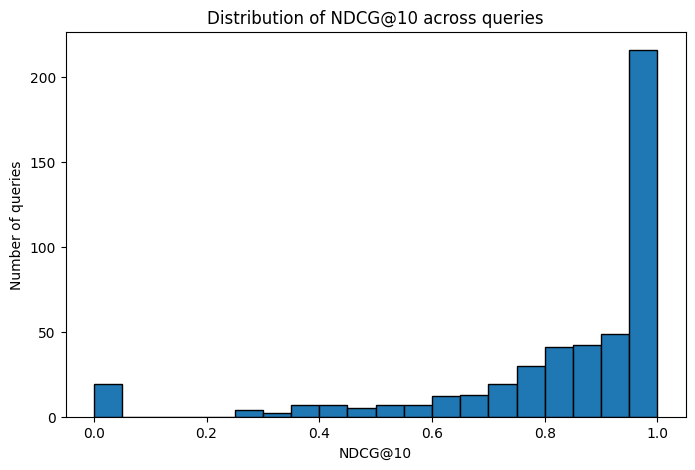

count    480.000000
mean       0.835308
std        0.234690
min        0.000000
25%        0.777827
50%        0.927366
75%        1.000000
max        1.000000
Name: ndcg, dtype: float64

In [23]:
# Task 5c: Analyze the distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(results_df["ndcg"], bins=20, edgecolor="black")
plt.xlabel("NDCG@10")
plt.ylabel("Number of queries")
plt.title("Distribution of NDCG@10 across queries")
plt.show()

# Optional quick stats
results_df["ndcg"].describe()


---

## Task 6: Improve Search with Additional Fields

Our baseline only searches the `product_name` field. Let's improve by adding more fields!

### 6a. Index product_class field

The `product_class` field contains the category of the product (e.g., "Rugs", "Coffee Tables"). This is a powerful signal!

Create a search function that combines all three fields (name, description, class).

In [24]:
# Task 6a: Index product_class field

# 1) Build BM25 index for product_class
class_docs = products["product_class"].fillna("").astype(str).tolist()
class_index, class_doc_lengths = build_index(class_docs, snowball_tokenize)

# 2) Define a 3-field search function (name + description + class)
# Assumes you already created:
# - name_index, name_doc_lengths   (from Task 3a)
# - desc_index, desc_doc_lengths   (from Task 3b)

def search_fn(query: str, k: int = 10) -> pd.DataFrame:
    # score each field
    name_scores = score_bm25(query, name_index, len(products), name_doc_lengths, snowball_tokenize)
    desc_scores = score_bm25(query, desc_index, len(products), desc_doc_lengths, snowball_tokenize)
    class_scores = score_bm25(query, class_index, len(products), class_doc_lengths, snowball_tokenize)

    # combine (simple sum). You can also weight these if you want.
    scores = name_scores + desc_scores + class_scores

    top_k_idx = np.argsort(-scores)[:k]
    results = products.iloc[top_k_idx].copy()
    results["score"] = scores[top_k_idx]
    results["rank"] = range(1, k + 1)
    return results

print("Three-field search_fn ready (name + description + class)!")


Three-field search_fn ready (name + description + class)!


### 6b. Evaluate three-field search

Now evaluate your three-field search on all queries to see how it compares to the baseline.

In [25]:
# Task 6b: Evaluate three-field search
results_df_3field = evaluate_search(
    search_fn,          # your 3-field search function
    products,           # products df
    queries,            # queries df
    labels,             # labels df
    k=10,
    verbose=True
)

print("Mean NDCG@10 (3-field):", results_df_3field["ndcg"].mean())
results_df_3field.head()




Evaluated 480 queries
Mean NDCG@10: 0.8792
Mean NDCG@10 (3-field): 0.8791953151801567


,query_id,query,ndcg
0,0,salon chair,1.000000
1,1,smart coffee table,1.000000
2,2,dinosaur,1.000000
3,3,turquoise pillows,0.897263
4,4,chair and a half recliner,0.812595


### 6c. Compare to baseline

Analyze which queries improved and which degraded when using three-field search.

In [26]:
# Task 6c: Compare to baseline
# Merge baseline and 3-field results on query_id
compare_df = results_df.merge(
    results_df_3field,
    on="query_id",
    suffixes=("_baseline", "_3field")
)

# Compute delta
compare_df["delta"] = compare_df["ndcg_3field"] - compare_df["ndcg_baseline"]

# Summary counts
improved = (compare_df["delta"] > 0).sum()
degraded = (compare_df["delta"] < 0).sum()
unchanged = (compare_df["delta"] == 0).sum()

print("Improved queries:", improved)
print("Degraded queries:", degraded)
print("Unchanged queries:", unchanged)

# Show examples
print("\nTop improvements:")
display(compare_df.sort_values("delta", ascending=False).head(10))

print("\nTop degradations:")
display(compare_df.sort_values("delta").head(10))



Improved queries: 252
Degraded queries: 109
Unchanged queries: 119

Top improvements:


,query_id,query_baseline,ndcg_baseline,query_3field,ndcg_3field,delta
353,359,french molding,0.000000,french molding,0.736728,0.736728
338,343,navy and peach bedding,0.289065,navy and peach bedding,1.000000,0.710935
339,344,ottoman bed queen,0.000000,ottoman bed queen,0.693426,0.693426
88,88,rose gold lounge,0.000000,rose gold lounge,0.688529,0.688529
447,454,carpet 5x6,0.356207,carpet 5x6,0.955024,0.598816
296,301,circle cabinet pulls,0.414437,circle cabinet pulls,1.000000,0.585563
288,292,decorative white pillow,0.422790,decorative white pillow,0.986043,0.563253
387,393,propane gas dryer,0.411834,propane gas dryer,0.961309,0.549475
84,84,full metal bed rose gold,0.458461,full metal bed rose gold,0.996349,0.537888
442,448,bed side table,0.471628,bed side table,1.000000,0.528372



Top degradations:


,query_id,query_baseline,ndcg_baseline,query_3field,ndcg_3field,delta
45,45,70s inspired furniture,0.693030,70s inspired furniture,0.000000,-0.693030
304,309,moen 5995 arbor one,0.946645,moen 5995 arbor one,0.289065,-0.657581
469,476,hardwood beds,0.964139,hardwood beds,0.528144,-0.435994
163,164,modern outdoor furniture,0.759439,modern outdoor furniture,0.333333,-0.426106
13,13,outdoor privacy wall,0.911677,outdoor privacy wall,0.500000,-0.411677
325,330,kari 2 piece,1.000000,kari 2 piece,0.659002,-0.340998
147,147,drum picture,0.624051,drum picture,0.289065,-0.334986
445,452,day bed indian,0.831555,day bed indian,0.500000,-0.331555
479,487,rack glass,0.315465,rack glass,0.000000,-0.315465
457,464,cake cutlery,0.997188,cake cutlery,0.693030,-0.304158


---

## Task 7: Query Understanding with LLM

Sometimes users search for "star wars rug" when they really want a "rug with Star Wars theme". An LLM can help us understand what the user is actually looking for!

### 7a. Extract product type from query

Write a function using LiteLLM with structured outputs (Pydantic) to extract key information from a query.

In [27]:
import os

os.environ["GOOGLE_API_KEY"] = "REDACTED_GOOGLE_API_KEY"   


In [28]:
from pydantic import BaseModel
from typing import Optional, List

class QueryInfo(BaseModel):
    product_type: Optional[str] = None
    theme: Optional[str] = None
    material: Optional[str] = None
    color: Optional[str] = None
    style: Optional[str] = None
    other_attributes: Optional[List[str]] = None


In [29]:
# Task 7a: Extract product type, theme, material, color, and any other information from the query

import os
from litellm import completion
from pydantic import BaseModel
from typing import Optional, List
import json
from dotenv import load_dotenv

# Reload environment variables to override any previous settings
load_dotenv(override=True)

# Remove Vertex routing variables
for k in ["VERTEX_PROJECT", "VERTEX_LOCATION", "GOOGLE_APPLICATION_CREDENTIALS"]:
    os.environ.pop(k, None)

# Verify API key is loaded from .env file
print("GOOGLE_API_KEY set:", os.environ.get("GOOGLE_API_KEY") is not None)
print("First 6 chars:", os.environ.get("GOOGLE_API_KEY", "")[:6])

GOOGLE_API_KEY set: True
First 6 chars: AIzaSy


In [2]:
# Task 7a: Extract product type, theme, material, color, and any other information you deem relevcant from the query

import os
from litellm import completion
from pydantic import BaseModel
from typing import Optional, List
import json

# Remove Vertex routing variables
for k in ["VERTEX_PROJECT", "VERTEX_LOCATION", "GOOGLE_APPLICATION_CREDENTIALS"]:
    os.environ.pop(k, None)

# Verify API key is loaded from .env file
print("GOOGLE_API_KEY set:", bool(os.getenv("GOOGLE_API_KEY")))
print("Key prefix: [REDACTED]")


# Define the Pydantic model for structured output
class QueryInfo(BaseModel):
    product_type: Optional[str] = None
    theme: Optional[str] = None
    material: Optional[str] = None
    color: Optional[str] = None
    style: Optional[str] = None
    other_attributes: Optional[List[str]] = None


def extract_query_info(query: str, model: str = "gemini/gemini-2.0-flash") -> QueryInfo:
    """Extract structured shopping intent from a query using LLM."""
    
    prompt = f"""
Extract structured shopping intent from this query.

Query: "{query}"

Return ONLY valid JSON (no markdown, no commentary) with these keys:
- product_type
- theme  
- material
- color
- style
- other_attributes

If a field is not mentioned, use null.
"""
    
    # Make API call
    resp = completion(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    
    # Get the response content
    content = resp.choices[0].message.content.strip()
    
    # Clean up markdown code blocks if present
    if content.startswith("```json"):
        content = content[7:]
    if content.startswith("```"):
        content = content[3:]
    if content.endswith("```"):
        content = content[:-3]
    content = content.strip()
    
    # Parse and validate with Pydantic
    try:
        return QueryInfo.model_validate_json(content)
    except Exception as e:
        data = json.loads(content)
        return QueryInfo(**data)

GOOGLE_API_KEY set: False
Key prefix: [REDACTED]


In [31]:
# Test your query understanding function by running it against these test queries
test_queries = [
    "star wars rug",
    "wooden coffee table",
    "blue leather sofa",
    "modern metal bookshelf"
]

for q in test_queries:
    info = extract_query_info(q)
    print(f"\nQuery: {q}")
    print(info.model_dump())






Query: star wars rug
{'product_type': 'rug', 'theme': 'star wars', 'material': None, 'color': None, 'style': None, 'other_attributes': None}

Query: wooden coffee table
{'product_type': 'coffee table', 'theme': None, 'material': 'wood', 'color': None, 'style': None, 'other_attributes': None}

Query: blue leather sofa
{'product_type': 'sofa', 'theme': None, 'material': 'leather', 'color': 'blue', 'style': None, 'other_attributes': None}

Query: modern metal bookshelf
{'product_type': 'bookshelf', 'theme': None, 'material': 'metal', 'color': None, 'style': 'modern', 'other_attributes': None}


### 7b. Create an LLM-enhanced search

Use the extracted product type to boost matching results. If the LLM identifies "rug" as the product type, boost products where `product_class` contains "rug".

In [32]:
# Task 7b: Create an LLM-enhanced search
def build_enhanced_query(info: QueryInfo, original_query: str) -> str:
    parts = []

    # core product type first (most important)
    if info.product_type:
        parts.append(info.product_type)

    # then descriptors
    if info.style:
        parts.append(info.style)
    if info.material:
        parts.append(info.material)
    if info.color:
        parts.append(info.color)

    # theme last
    if info.theme:
        parts.append(info.theme)

    # any extra attributes (if list or string)
    if info.other_attributes:
        if isinstance(info.other_attributes, list):
            parts.extend([x for x in info.other_attributes if x])
        else:
            parts.append(str(info.other_attributes))

    enhanced = " ".join(parts).strip()
    return enhanced if enhanced else original_query


In [33]:
# Test the LLM-enhanced search
for q in test_queries:
    info = extract_query_info(q)
    enhanced = build_enhanced_query(info, q)
    print("\nOriginal:", q)
    print("Enhanced:", enhanced)
    print("Fields:", info.model_dump())




Original: star wars rug
Enhanced: rug star wars
Fields: {'product_type': 'rug', 'theme': 'star wars', 'material': None, 'color': None, 'style': None, 'other_attributes': None}

Original: wooden coffee table
Enhanced: coffee table wood
Fields: {'product_type': 'coffee table', 'theme': None, 'material': 'wood', 'color': None, 'style': None, 'other_attributes': None}

Original: blue leather sofa
Enhanced: sofa leather blue
Fields: {'product_type': 'sofa', 'theme': None, 'material': 'leather', 'color': 'blue', 'style': None, 'other_attributes': None}

Original: modern metal bookshelf
Enhanced: bookshelf modern metal
Fields: {'product_type': 'bookshelf', 'theme': None, 'material': 'metal', 'color': None, 'style': 'modern', 'other_attributes': None}


---
## Task 8: Submit via Pull Request

Now let's submit your work using the Git workflow from previous homeworks.
- [ ] Create a new branch called `homework-3`
- [ ] Commit you work and push it to the branch
- [ ] Create a PR with a nice description of your changes
- [ ] Merge the PR to your main branch
  
**The TA will verify your submission by checking the merged PR on your GitHub repo.**

**Also remember to submit your homework on Blackboard!**
